### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

### Step 2: Load Dataset 

In [3]:
df = pd.read_csv("austin_weather.csv")
df.head()

,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
0,2013-12-21,74,60,45,67,49,43,93,75,57,29.86,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
1,2013-12-22,56,48,39,43,36,28,93,68,43,30.41,30.13,29.87,10,10,5,16,6,25,0,
2,2013-12-23,58,45,32,31,27,23,76,52,27,30.56,30.49,30.41,10,10,10,8,3,12,0,
3,2013-12-24,61,46,31,36,28,21,89,56,22,30.56,30.45,30.3,10,10,7,12,4,20,0,
4,2013-12-25,58,50,41,44,40,36,86,71,56,30.41,30.33,30.27,10,10,7,10,2,16,T,


### Step 3: Explore Dataset 

In [4]:
df.shape

(1319, 21)

In [5]:
df.columns

Index(['Date', 'TempHighF', 'TempAvgF', 'TempLowF', 'DewPointHighF',
       'DewPointAvgF', 'DewPointLowF', 'HumidityHighPercent',
       'HumidityAvgPercent', 'HumidityLowPercent',
       'SeaLevelPressureHighInches', 'SeaLevelPressureAvgInches',
       'SeaLevelPressureLowInches', 'VisibilityHighMiles',
       'VisibilityAvgMiles', 'VisibilityLowMiles', 'WindHighMPH', 'WindAvgMPH',
       'WindGustMPH', 'PrecipitationSumInches', 'Events'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Date                        1319 non-null   object
 1   TempHighF                   1319 non-null   int64 
 2   TempAvgF                    1319 non-null   int64 
 3   TempLowF                    1319 non-null   int64 
 4   DewPointHighF               1319 non-null   object
 5   DewPointAvgF                1319 non-null   object
 6   DewPointLowF                1319 non-null   object
 7   HumidityHighPercent         1319 non-null   object
 8   HumidityAvgPercent          1319 non-null   object
 9   HumidityLowPercent          1319 non-null   object
 10  SeaLevelPressureHighInches  1319 non-null   object
 11  SeaLevelPressureAvgInches   1319 non-null   object
 12  SeaLevelPressureLowInches   1319 non-null   object
 13  VisibilityHighMiles         1319 non-null   obje

In [7]:
df.describe()

,TempHighF,TempAvgF,TempLowF
count,1319.000000,1319.000000,1319.000000
mean,80.862775,70.642911,59.902957
std,14.766523,14.045904,14.190648
min,32.000000,29.000000,19.000000
25%,72.000000,62.000000,49.000000
50%,83.000000,73.000000,63.000000
75%,92.000000,83.000000,73.000000
max,107.000000,93.000000,81.000000


### Step 4: Check Missing Values

In [8]:
df.isnull().sum()

Date                          0
TempHighF                     0
TempAvgF                      0
TempLowF                      0
DewPointHighF                 0
DewPointAvgF                  0
DewPointLowF                  0
HumidityHighPercent           0
HumidityAvgPercent            0
HumidityLowPercent            0
SeaLevelPressureHighInches    0
SeaLevelPressureAvgInches     0
SeaLevelPressureLowInches     0
VisibilityHighMiles           0
VisibilityAvgMiles            0
VisibilityLowMiles            0
WindHighMPH                   0
WindAvgMPH                    0
WindGustMPH                   0
PrecipitationSumInches        0
Events                        0
dtype: int64

### Step 5: Replace Invalid Symbols 

In [9]:
df.replace("T", np.nan, inplace=True)
df.replace("-", np.nan, inplace=True)

### Step 6: Convert Date Column

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

### Step 6: Drop Unnecessary Columns 

In [11]:
df.drop(["Date", "Events"], axis=1, inplace=True)

### Step 8: Convert Columns into Numeric 

In [12]:
df = df.apply(pd.to_numeric)

### Step 9: Handle Missing Values

In [13]:
df.fillna(df.median(), inplace=True)

### Step 10: Verify Missing Values 

In [14]:
df.isnull().sum()

TempHighF                     0
TempAvgF                      0
TempLowF                      0
DewPointHighF                 0
DewPointAvgF                  0
DewPointLowF                  0
HumidityHighPercent           0
HumidityAvgPercent            0
HumidityLowPercent            0
SeaLevelPressureHighInches    0
SeaLevelPressureAvgInches     0
SeaLevelPressureLowInches     0
VisibilityHighMiles           0
VisibilityAvgMiles            0
VisibilityLowMiles            0
WindHighMPH                   0
WindAvgMPH                    0
WindGustMPH                   0
PrecipitationSumInches        0
dtype: int64

### Step 11: Correlation Matrix

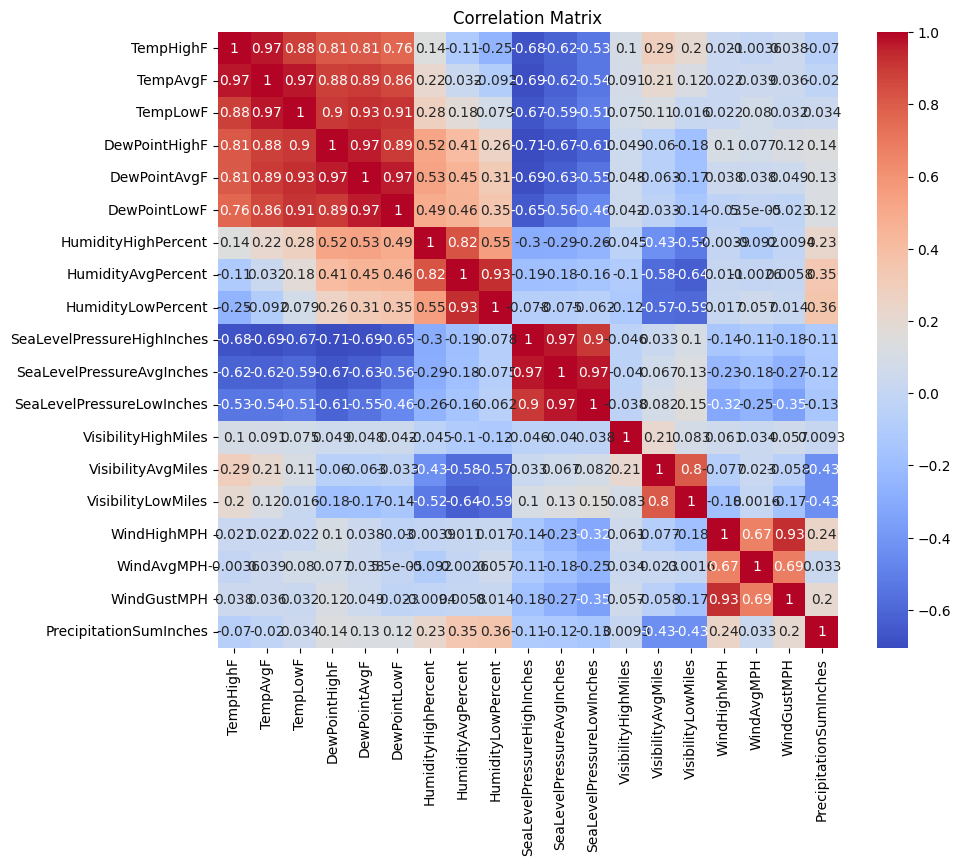

In [18]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), 
           annot=True, 
           cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### Step 12: Rainfall Distribution 

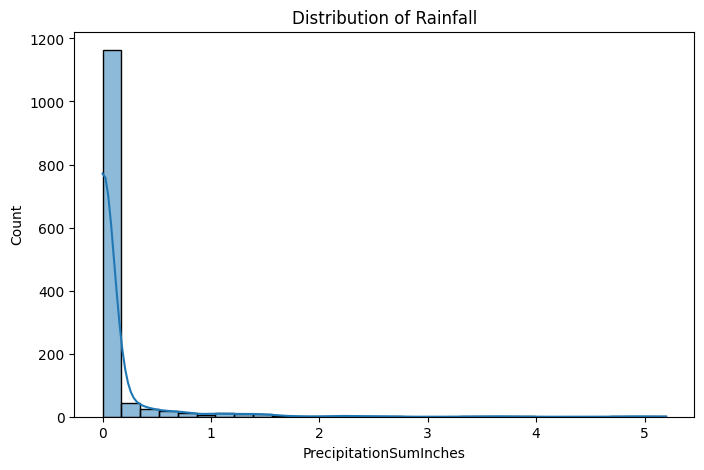

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(df["PrecipitationSumInches"], 
            bins=30, 
            kde=True)

plt.title("Distribution of Rainfall")
plt.show()

### Step 13: Temperature vs Rainfall 

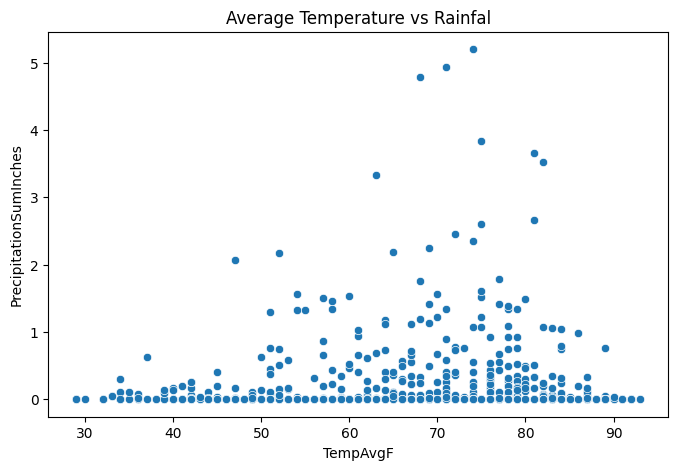

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x = df["TempAvgF"], 
    y = df["PrecipitationSumInches"]
)

plt.title("Average Temperature vs Rainfal")
plt.show()

### Step 14: Humidity vs Rainfall 

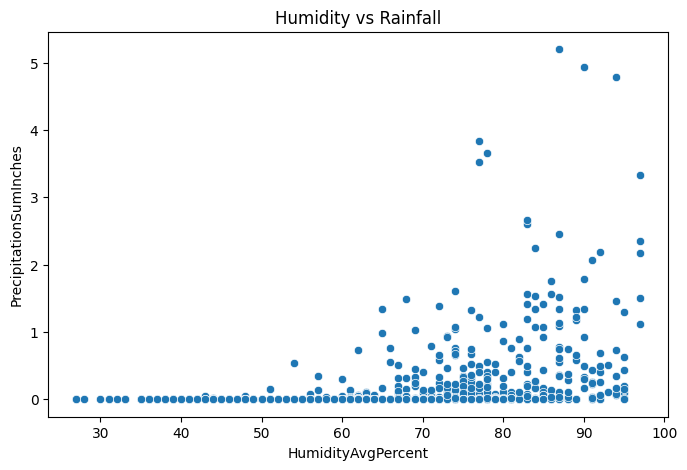

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x = df["HumidityAvgPercent"], 
    y = df["PrecipitationSumInches"]
)

plt.title("Humidity vs Rainfall") 
plt.show()

### Step 15. Wind Speed vs Rainfall 

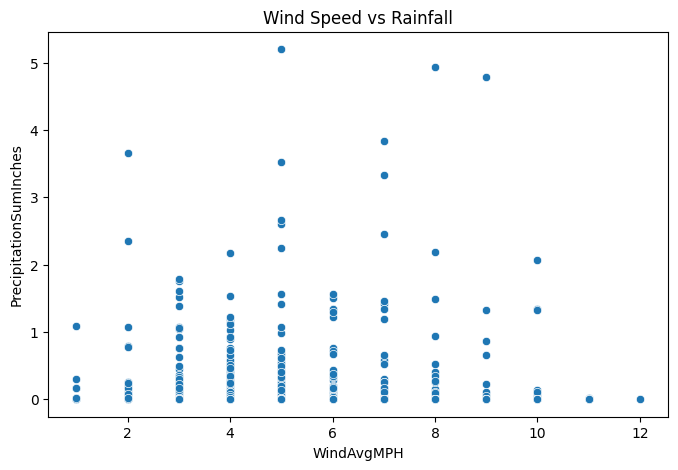

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x = df["WindAvgMPH"], 
    y = df["PrecipitationSumInches"]
)

plt.title("Wind Speed vs Rainfall")
plt.show()

### Step 16: Define Features and Target

In [24]:
x = df.drop("PrecipitationSumInches", axis=1)
y = df["PrecipitationSumInches"]

### Step 17: Train- Test Split 

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Step 18: Train Linear Regression Model

In [26]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

### Step 19: Predict 

In [28]:
y_pred = model.predict(x_test)
y_pred

array([ 2.02013612e-02,  1.76196409e-01, -1.33453992e-01,  3.30061505e-01,
        7.91852299e-01,  8.99565389e-02,  1.00076452e-01, -2.11554646e-01,
        1.85314475e-01,  3.42550357e-01,  1.57610010e-01,  5.09678471e-01,
       -1.81988700e-02,  2.60826538e-01,  8.08670080e-02,  3.65580938e-01,
        5.98674067e-01,  9.13758673e-02, -8.97264966e-03, -1.81362417e-02,
       -1.25909313e-02,  1.75916230e-01, -3.51067663e-02,  7.45666415e-03,
        1.23616254e-01,  1.49118675e-01,  4.57711342e-01,  5.58797632e-01,
       -3.19607633e-02, -1.31849468e-01,  3.02097516e-01, -2.46064304e-02,
        3.78705789e-01,  2.82047761e-01,  2.52183824e-01,  7.23241899e-02,
        3.49442945e-01,  6.78205939e-02,  2.23928668e-01,  3.41160839e-01,
        6.22813434e-01,  7.28077155e-02, -1.89606682e-01, -1.97724759e-01,
        4.51997557e-01,  2.92753952e-02, -1.60812484e-01, -1.87886062e-01,
        3.31464195e-01,  5.45032173e-01,  4.88509025e-01,  2.65413921e-02,
       -8.21945672e-02, -

### Step 20: Model Evaluation

In [29]:
# Mean Absolute Error 
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae) 

# Mean Squared Error 
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse) 

# R2 Score 
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2) 

MAE: 0.18631222872121367
MSE: 0.11065629936701395
R2 Score: 0.06749601456175225


# Step 21: Actual vs Predicted Values 

In [30]:
comparison = pd.DataFrame({
    "Actual": y_test, 
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
677,0.00,0.020201
1046,0.33,0.176196
610,0.00,-0.133454
49,0.00,0.330062
1284,0.01,0.791852
486,0.00,0.089957
548,0.00,0.100076
939,0.00,-0.211555
78,0.11,0.185314
506,0.40,0.342550


### Step 22: Plot Actual vs Predicted 

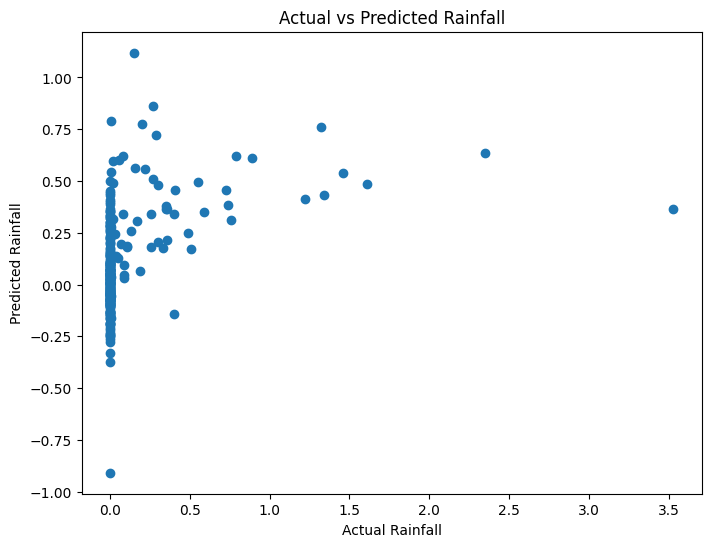

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted Rainfall")
plt.show()

### Step 23: Residual Plot 

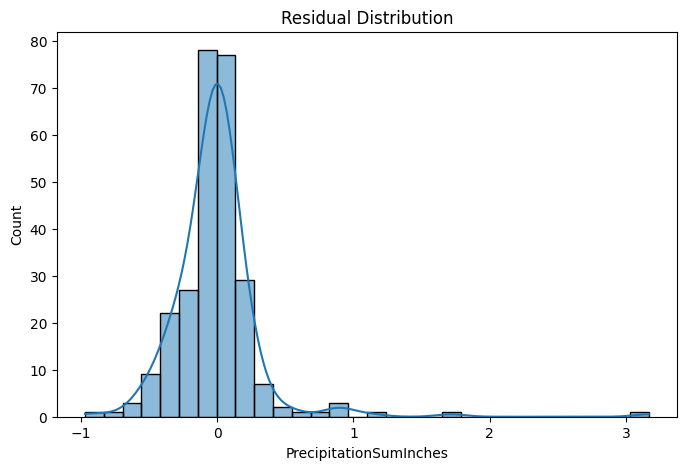

In [32]:
residuals = y_test - y_pred 
plt.figure(figsize=(8,5))

sns.histplot(residuals, 
            bins=30, 
            kde=True)

plt.title("Residual Distribution")
plt.show()

### Step 24: Feature Importance(Coefficients)

In [33]:
coefficients = pd.DataFrame({
    "Feature": x.columns, 
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by = "Coefficient",
    ascending = False
)

,Feature,Coefficient
9,SeaLevelPressureHighInches,0.306900
12,VisibilityHighMiles,0.250195
11,SeaLevelPressureLowInches,0.223672
0,TempHighF,0.057236
2,TempLowF,0.055646
15,WindHighMPH,0.052539
8,HumidityLowPercent,0.020221
5,DewPointLowF,0.014158
3,DewPointHighF,0.012555
6,HumidityHighPercent,0.011302


### Step 25: Predict New Rainfall 

In [34]:
sample = x.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Rainfall:", prediction[0])

Predicted Rainfall: 1.0001701255443973


In [36]:
sample = x.iloc[[3]]

prediction = model.predict(sample)

print("Predicted Rainfall:", prediction[0])

Predicted Rainfall: -0.15567989292113565


In [43]:
sample = x.iloc[[83]]

prediction = model.predict(sample)

print("Predicted Rainfall:", prediction[0])

Predicted Rainfall: 0.03656266606753028
